# Qwen/Qwen2-VL-7B-Instruct
https://huggingface.co/learn/cookbook/fine_tuning_vlm_trl

In [1]:
import os
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb=256'
os.environ['PYTORCH_CUDA_ALLOC_CONF']='expandable_segments:True'
from unsloth import FastVisionModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## 1. Install Dependency

In [ ]:
!pip install -U -q git+https://github.com/huggingface/trl.git bitsandbytes peft qwen-vl-utils trackio
# trackio
# Tested with trl==0.22.0.dev0, bitsandbytes==0.47.0, peft==0.17.1, qwen-vl-utils==0.0.11, trackio==0.2.8

In [ ]:
%pip install qwen-vl-utils[decord]==0.0.8

In [ ]:
# %pip install flash-attn --no-build-isolation

In [ ]:
%pip install unsloth

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

## 2. Load Dataset

In [2]:
# Download Dataset from Hugging Face Hub
from datasets import load_dataset
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
import os

def dowload_kvasir_vqa_x1():
    # Folder to save images and JSONLs
    d_path = "/home/qzhao9/datasets/Kvasir-VQA-x1/"
    img_dir = Path(os.path.abspath(os.path.join(d_path, "images")))
    img_dir.mkdir(exist_ok=True, parents=True)

    # Save images once from SimulaMet-HOST/Kvasir-VQA
    # ds_host = load_dataset("SimulaMet-HOST/Kvasir-VQA", split="raw")
    # seen = set()
    # for row in tqdm(ds_host, desc="Saving images"):
    #     if row["img_id"] not in seen:
    #         row["image"].save(img_dir / f"{row['img_id']}.jpg")
    #         seen.add(row["img_id"])

    # Save VLM-ready JSONLs for SimulaMet/Kvasir-VQA-x1
    with open(f"{d_path}/Kvasir-VQA-x1-train.jsonl", "w", encoding="utf-8") as f:
        for r in load_dataset("SimulaMet/Kvasir-VQA-x1", split="train"):
            f.write(json.dumps({
                "question": r["question"],
                "answer": r["answer"],
                "image": str(img_dir / f"{r['img_id']}.jpg")
            }, ensure_ascii=False) + "\n")

    with open(f"{d_path}/Kvasir-VQA-x1-val.jsonl", "w", encoding="utf-8") as f_val:
        with open(f"{d_path}/Kvasir-VQA-x1-test.jsonl", "w", encoding="utf-8") as f_test:        
            for r in load_dataset("SimulaMet/Kvasir-VQA-x1", split='test'):
                if np.random.random() < 0.1:
                    f = f_val
                else:
                    f = f_test
                f.write(json.dumps({
                    "question": r["question"],
                    "answer": r["answer"],
                    "image": str(img_dir / f"{r['img_id']}.jpg")
                }, ensure_ascii=False) + "\n")
        
    # for split in ["train", "test"]:
    #     with open(f"{d_path}/Kvasir-VQA-x1-{split}.jsonl", "w", encoding="utf-8") as f:
    #         for r in load_dataset("SimulaMet/Kvasir-VQA-x1", split=split):
    #             f.write(json.dumps({
    #                 # "messages": [
    #                 #     {"role": "user", "content": f"<image>{r['question']}"},
    #                 #     {"role": "assistant", "content": r["answer"]}
    #                 # ],
    #                 # "images": [str(img_dir / f"{r['img_id']}.jpg")]
    #                 "question": r["question"],
    #                 "answer": r["answer"],
    #                 "image": str(img_dir / f"{r['img_id']}.jpg")
    #             }, ensure_ascii=False) + "\n")
# dowload_kvasir_vqa_x1()

In [3]:
system_message = """You are a Vision Language Model specialized in interpreting visual data from colonoscopy images.
Your task is to analyze the provided colonoscopy image and respond to queries with concise answers, usually a single word, number, or short phrase.
The images include a variety of types and contain colors, labels, and text.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary."""

In [4]:
from PIL import Image

def format_data(sample):
    img = sample["image"] #Image.open(sample["image"]).convert("RGB")
    return {
    #   "images": [img],
      "messages": [

        #   {
        #       "role": "system",
        #       "content": [
        #           {
        #               "type": "text",
        #               "text": system_message
        #           }
        #       ],
        #   },
          {
              "role": "user",
              "content": [
                  {
                      "type": "image",
                      "image": img,
                  },
                  {
                      "type": "text",
                      "text": sample['question'],
                  }
              ],
          },
          {
              "role": "assistant",
              "content": [
                  {
                      "type": "text",
                      "text": sample["answer"]
                  }
              ],
          },
      ]
      }

In [5]:
from datasets import load_dataset

# dataset_id = "SimulaMet-HOST/Kvasir-VQA" #"HuggingFaceM4/ChartQA"
# train_dataset, eval_dataset, test_dataset = load_dataset(dataset_id, split=['train[:1%]', 'val[:1%]', 'test[:1%]'])
train_dataset,eval_dataset,test_dataset = load_dataset("/home/qzhao9/datasets/Kvasir-VQA-x1", split=['train[:]','validation', 'test[:]'])

In [6]:
len(train_dataset),len(eval_dataset),len(test_dataset)

(143594, 1609, 14346)

In [7]:
len(train_dataset)/len(eval_dataset)


89.24425108763207

In [8]:
train_dataset = [format_data(sample) for sample in train_dataset]
eval_dataset = [format_data(sample) for sample in eval_dataset]
test_dataset = [format_data(sample) for sample in test_dataset]

## 3. Load Model and Check Performance

In [ ]:
# from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
# from qwen_vl_utils import process_vision_info
# import torch

# model_id = 'unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit'
model_id = 'Qwen/Qwen2.5-VL-3B-Instruct'

In [10]:
import torch

model, tokenizer = FastVisionModel.from_pretrained(model_id,
                                                   load_in_4bit=True,
                                                   use_gradient_checkpointing='unsloth')

model = FastVisionModel.get_peft_model(model,
                                       target_modules=["q_proj","k_proj", "v_proj", "o_proj", "up_proj", "down_proj"],
                                       finetune_vision_layers=True,
                                       finetune_language_layers=True,
                                       finetune_attention_modules=True,
                                       finetune_mlp_modules=True,
                                       r=16,
                                       lora_alpha=16,
                                       lora_dropout=0.00,
                                       bias="none",
                                       random_seed=42,
                                       use_rslora=False,
                                       loftq_config=None
                                       
                                       )

==((====))==  Unsloth 2025.12.9: Fast Qwen2_5_Vl patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 3070 Laptop GPU. Num GPUs = 1. Max memory: 7.648 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [10]:
from qwen_vl_utils import process_vision_info

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Prepare the text input by applying the chat template
    text_input = processor.apply_chat_template(
        sample['messages'][0:1],  # Use the sample without the system message
        tokenize=False,
        add_generation_prompt=True
    )

    # Process the visual input from the sample
    image_inputs, _ = process_vision_info(sample['messages'])

    # Prepare the inputs for the model
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)  # Move inputs to the specified device
    # Generate text with the model
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens, temperature=0.01)
    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    # Decode the output text
    output_text = processor.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]  # Return the first decoded output text

In [62]:
# Example of how to call the method with sample:
FastVisionModel.for_inference(model)

data = train_dataset[1]
print(data)
output = generate_text_from_sample(model, tokenizer, data)
output

{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': '/home/qzhao9/datasets/Kvasir-VQA-x1/images/cl8k2u1r71foz083278j63qnm.jpg'}, {'type': 'text', 'text': 'What procedure is depicted in the image and what type of polyp is observed?'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Evidence of a colonoscopy with a paris iia polyp noted'}]}]}


'Evidence of colonoscopy findings with a Paris IIa polyp detected'

In [11]:
import gc
import time

def clear_memory():
    # Delete variables if they exist in the current global scope
    if 'inputs' in globals(): del globals()['inputs']
    if 'model' in globals(): del globals()['model']
    if 'processor' in globals(): del globals()['processor']
    if 'trainer' in globals(): del globals()['trainer']
    if 'bnb_config' in globals(): del globals()['bnb_config']
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

# clear_memory()

## 4. Fine-Tune the Model using TRL

In [12]:
from trl import SFTConfig

# Configure training arguments
training_args = SFTConfig(
    output_dir="qwen2.5-3b-instruct-trl-sft-ChartQA",  # Directory to save the model
    num_train_epochs=3,  # Number of training epochs
    per_device_train_batch_size=1,  # Batch size for training
    per_device_eval_batch_size=1,  # Batch size for evaluation
    gradient_accumulation_steps=16,  # Steps to accumulate gradients
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Options for gradient checkpointing
    # max_length=None,
    # Optimizer and scheduler settings
    optim="adamw_8bit",  # Optimizer type
    learning_rate=2e-4,  # Learning rate for training
    weight_decay=0.001,  # Weight decay for optimizer
    lr_scheduler_type="linear",  # Learning rate scheduler type
    # Logging and evaluation
    logging_steps=10,  # Steps interval for logging
    eval_steps=100,  # Steps interval for evaluation
    eval_strategy="steps",  # Strategy for evaluation
    save_strategy="steps",  # Strategy for saving the model
    save_steps=100,  # Steps interval for saving
    # Mixed precision and gradient settings
    bf16=True,  # Use bfloat16 precision
    max_grad_norm=0.3,  # Maximum norm for gradient clipping
    warmup_ratio=0.03,  # Ratio of total steps for warmup
    # Hub and reporting
    push_to_hub=False,  # Whether to push model to Hugging Face Hub
    report_to="trackio",  # Reporting tool for tracking metrics
    remove_unused_columns=False,  # Whether to remove unused columns from the dataset
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    max_length=2048,
)

In [16]:
import trackio

trackio.init(
    project="qwen25-3b-instruct-trl-sft-ChartQA",
    name="qwen25-3b-instruct-trl-sft-ChartQA",
    config=training_args,
    space_id=training_args.output_dir + "-trackio"
)

* Trackio project initialized: qwen25-3b-instruct-trl-sft-ChartQA
* Trackio metrics will be synced to Hugging Face Dataset: qzhao9/qwen2.5-3b-instruct-trl-sft-ChartQA-trackio-dataset
* Found existing space: https://huggingface.co/spaces/qzhao9/qwen2.5-3b-instruct-trl-sft-ChartQA-trackio
* View dashboard by going to: https://qzhao9-qwen2.5-3b-instruct-trl-sft-ChartQA-trackio.hf.space/


* Created new run: qwen25-3b-instruct-trl-sft-ChartQA


In [17]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_dataset,
    args=training_args,
    eval_dataset=eval_dataset,
    # peft_config=peft_config,
)

Unsloth: Model does not have a default image size - using 512


In [18]:
# trainer.train()
from unsloth import unsloth_train
trainer_stats = unsloth_train(trainer)

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 143,594 | Num Epochs = 3 | Total steps = 26,925
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 27,226,112 of 3,781,849,088 (0.72% trained)


* Trackio project initialized: huggingface
* Trackio metrics will be synced to Hugging Face Dataset: qzhao9/trackio-dataset
* Found existing space: https://huggingface.co/spaces/qzhao9/trackio
* View dashboard by going to: https://qzhao9-trackio.hf.space/


* Created new run: qzhao9-1767141362


Step,Training Loss,Validation Loss
100,1.708400,1.538283
200,0.566700,0.550632
300,0.481300,0.469821
400,0.456000,0.433920
500,0.430000,0.424356
600,0.417600,0.417469
700,0.401800,0.400241
800,0.424200,0.394885
900,0.404300,0.385809
1000,0.404400,0.377970


Unsloth: Not an error, but Qwen2_5_VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Exception in thread Thread-18 (_init_client_background):
Traceback (most recent call last):
  File "/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/httpx/_transports/default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/httpcore/_sync/connection_pool.py", line 256, in handle_request
    raise exc from None
  File "/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/httpcore/_sync/connection_pool.py", line 236, in handle_request
    respo

KeyboardInterrupt: 

In [19]:
trainer.save_model(training_args.output_dir)

In [22]:
metrics = trainer.evaluate(test_dataset)
print(metrics)

{'eval_loss': 0.28269514441490173}


In [13]:
from rouge_score import rouge_scorer
import bert_score as bert

def measurement_metrics(preds, labels):
    rouge_score = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    bert_scores = bert.score(preds, 
                                labels, 
                                model_type='microsoft/deberta-xlarge-mnli',
                                lang='en', 
                                rescale_with_baseline=True)

    rouge1 = np.mean([rouge_score.score(l, p)['rouge1'].fmeasure for l, p in zip(labels, preds)])
    rouge2 = np.mean([rouge_score.score(l, p)['rouge2'].fmeasure for l, p in zip(labels, preds)])
    rougeL = np.mean([rouge_score.score(l, p)['rougeL'].fmeasure for l, p in zip(labels, preds)])
    bert_f1 = np.mean(bert_scores[2].numpy())

    return {
        'rouge1': rouge1,
        'rouge2': rouge2,
        'rougeL': rougeL,
        'bert_f1': bert_f1
    }


In [ ]:
preds = []
labels = []
outputs=[]
model.eval()
for sample in tqdm(test_dataset[:]):
    output = generate_text_from_sample(model, tokenizer, sample)
    preds.append(output)
    labels.append(sample['messages'][-1]['content'][0]['text'])
    outputs.append({
        'prediction': output,
        'label': labels[-1]
    })
    
with open('qwen2.5-3b-instruct-kvasir-vqa-x1-predictions.jsonl', 'w', encoding='utf-8') as f:
    json.dump(outputs, f)

print('saved prediction results.')
metrics = measurement_metrics(preds, labels)
print(metrics)

100%|██████████| 14346/14346 [6:19:08<00:00,  1.59s/it]  


saved prediction results.
{'rouge1': 0.7303423599166626, 'rouge2': 0.5379323335338653, 'rougeL': 0.7013445058905151, 'bert_f1': 0.74623615}


## 5. Testing the Fine-Tuned Model

In [25]:
clear_memory()

GPU allocated memory: 0.60 GB
GPU reserved memory: 0.65 GB


In [14]:
# model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#     model_id,
#     device_map="auto",
#     dtype=torch.bfloat16,
# )

# processor = AutoProcessor.from_pretrained(model_id)
model, tokenizer = FastVisionModel.from_pretrained(model_id,
                                                   load_in_4bit=True,
                                                   use_gradient_checkpointing='unsloth')

==((====))==  Unsloth 2025.12.9: Fast Qwen2_5_Vl patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 3070 Laptop GPU. Num GPUs = 1. Max memory: 7.648 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [15]:
from peft import PeftModel

adapter_path = training_args.output_dir
# model.load_adapter(adapter_path,assign=True)

model = PeftModel.from_pretrained(model, adapter_path)


In [ ]:
eval_dataset[100]['messages']

In [63]:
FastVisionModel.for_inference(model)

output = generate_text_from_sample(model, tokenizer, train_dataset[1])
output

'Evidence of colonoscopy findings with a Paris IIa polyp detected'

{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': '/home/qzhao9/datasets/Kvasir-VQA-x1/images/cla820glps4rz071u6kspddxw.jpg'}, {'type': 'text', 'text': 'Where is the anatomical landmark located in the image and have all polyps been removed?'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Anatomical landmark is seen in the upper-center and upper-right regions, and polyp removal is not applicable.'}]}]}


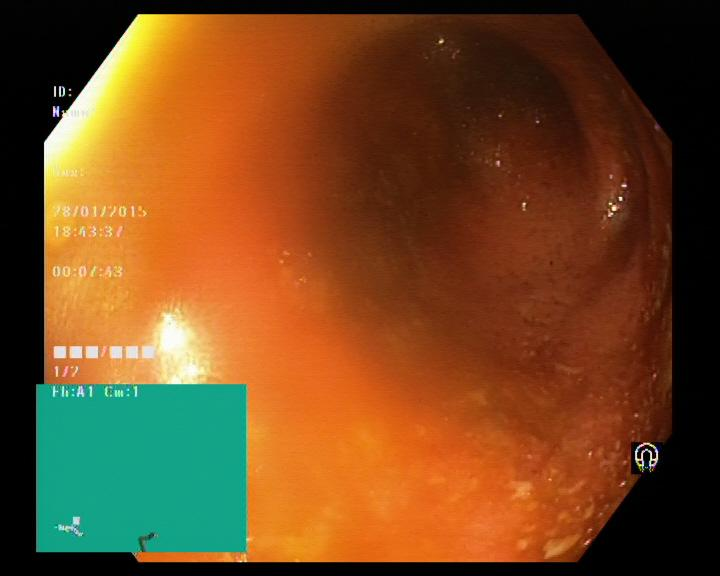

'Anatomical landmark is seen in upper-central and upper-right regions; no evidence of residual polyps'

In [108]:
from IPython.display import display
from PIL import Image
data = eval_dataset[1200]
print(data)
display(Image.open(data['messages'][0]['content'][0]['image']))
output = generate_text_from_sample(model, tokenizer, data)
output

In [ ]:
clear_memory()